<div style="display: flex; background-color: #FF5A5F;" >
<h1 style="margin: auto; padding: 30px; color: white; ">Project 10 - Part 1 - Exploratory analysis - Airbnb listings</h1>
</div>

<div style="background-color: #767676;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Importing libraries and loading the files</h2>
</div>

In [1]:
# Import libraries
import pandas as pd
import reverse_geocoder as rg
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Load the dataset with only the columns we need
colonnes_finales = [
    "ID",
    "Name",
    "Host ID",
    "Host Since",
    "First Review",
    "Last Review",
    "Host Total Listings Count",
    "Latitude",
    "Longitude",
    "City",
    "Country Code",
    "Country",
    "Property Type",
    "Room Type",
    "Accommodates",
    "Bathrooms",
    "Bedrooms",
    "Beds",
    "Price",
    "Security Deposit",
    "Cleaning Fee",
    "Minimum Nights",
    "Number of Reviews",
    "Review Scores Rating",
    "Cancellation Policy",
    "Availability 365",
]
df = pd.read_csv("../data/raw/airbnb-listings.csv", sep=";", usecols=colonnes_finales)

/var/folders/yn/3_wmrcjj4bz_6hz4_nqjgfdw0000gn/T/ipykernel_60112/2314770651.py:30: DtypeWarning: Columns (0: ID) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("airbnb-listings.csv", sep=";", usecols=colonnes_finales)


<div style="background-color: #767676;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Exploratory analysis</h2>
</div>

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.1 - Exploring the file</h3>
</div>

In [3]:
# Size of the loaded dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 494954 entries, 0 to 494953
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         494954 non-null  object 
 1   Name                       494536 non-null  str    
 2   Host ID                    494954 non-null  int64  
 3   Host Since                 494449 non-null  str    
 4   Host Total Listings Count  494448 non-null  float64
 5   City                       494500 non-null  str    
 6   Country Code               494952 non-null  str    
 7   Country                    494951 non-null  str    
 8   Latitude                   494953 non-null  float64
 9   Longitude                  494953 non-null  float64
 10  Property Type              494943 non-null  str    
 11  Room Type                  494953 non-null  str    
 12  Accommodates               494891 non-null  float64
 13  Bathrooms                  493428 non-nu

In [4]:
# Descriptive statistics
df.describe()

,Host ID,Host Total Listings Count,Latitude,Longitude,Accommodates,Bathrooms,Bedrooms,Beds,Price,Security Deposit,Cleaning Fee,Minimum Nights,Availability 365,Number of Reviews,Review Scores Rating
count,4.949540e+05,494448.000000,494953.000000,494953.000000,494891.000000,493428.000000,494328.000000,494037.000000,486996.000000,204012.000000,315715.000000,494952.000000,494952.000000,494952.000000,367134.000000
mean,3.234417e+07,9.549738,38.042292,-15.020974,3.311584,1.249632,1.378322,1.934525,138.072703,274.126703,62.267906,3.470415,166.092332,16.740850,92.913988
std,3.172156e+07,57.199579,22.941429,70.364294,2.094052,0.607029,0.942508,1.488128,149.670499,171.605763,75.746943,89.396359,140.510625,32.336701,8.543725
min,1.900000e+01,0.000000,-38.224427,-123.218712,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000
25%,6.886060e+06,1.000000,38.913119,-73.969216,2.000000,1.000000,1.000000,1.000000,55.000000,150.000000,20.000000,1.000000,14.000000,1.000000,90.000000
50%,2.188181e+07,1.000000,42.310894,2.137584,2.000000,1.000000,1.000000,1.000000,90.000000,200.000000,40.000000,2.000000,148.000000,4.000000,95.000000
75%,4.792177e+07,3.000000,51.375424,12.444849,4.000000,1.000000,2.000000,2.000000,150.000000,350.000000,75.000000,3.000000,313.000000,18.000000,100.000000
max,1.350885e+08,1114.000000,55.994889,153.637837,21.000000,10.000000,96.000000,19.000000,999.000000,999.000000,999.000000,60000.000000,365.000000,735.000000,100.000000


In [5]:
# First 5 rows
df.head()

,ID,Name,Host ID,Host Since,Host Total Listings Count,City,Country Code,Country,Latitude,Longitude,...,Price,Security Deposit,Cleaning Fee,Minimum Nights,Availability 365,Number of Reviews,First Review,Last Review,Review Scores Rating,Cancellation Policy
0,4008728,"Luxurious 3 bedroom, centrum, 180m2",20786453,2014-09-01,1.0,Amsterdam,NL,Netherlands,52.365237,4.878250,...,600.0,500.0,50.0,2.0,74.0,31.0,2015-08-02,2016-11-27,89.0,strict
1,7778612,Luxury apartment in city centre,11964927,2014-02-05,1.0,Amsterdam,NL,Netherlands,52.367309,4.873841,...,175.0,400.0,40.0,2.0,259.0,15.0,2015-09-28,2017-01-19,99.0,strict
2,8264596,Cosy apartment across Vondelpark,23669273,2014-11-12,1.0,Amsterdam,NL,Netherlands,52.361944,4.866687,...,125.0,NaN,NaN,4.0,0.0,1.0,2015-09-22,2015-09-22,100.0,flexible
3,2180729,Spacious City Apartment Oud-West,9238680,2013-10-05,1.0,Amsterdam,NL,Netherlands,52.370146,4.866282,...,130.0,100.0,45.0,3.0,0.0,22.0,2014-05-12,2016-07-19,97.0,flexible
4,14463171,Cosy Studio Apartment Center Amsterdam,89112644,2016-08-10,1.0,Amsterdam,NL,Netherlands,52.368818,4.871249,...,80.0,100.0,25.0,2.0,326.0,16.0,2016-08-11,2017-03-06,78.0,moderate


<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.2 - Date variables</h3>
</div>

In [6]:
# Convert the date columns (str) to datetime
for col in ["Host Since", "First Review", "Last Review"]:
    df[col] = pd.to_datetime(df[col])

In [7]:
# Check the conversion
df[["Host Since", "First Review", "Last Review"]].dtypes

Host Since      datetime64[us]
First Review    datetime64[us]
Last Review     datetime64[us]
dtype: object

In [8]:
# Time frame of the analysis
print("Date min:", df["First Review"].min())
print("Date max:", df["Last Review"].max())

Date min: 2008-06-22 00:00:00
Date max: 2017-06-15 00:00:00


Our study covers 9 years, from June 2008 to June 2017.

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.3 - "Minimum Nights"</h3>
</div>

In [9]:
# Abnormal Minimum Nights values
mini_night_anormal = (df["Minimum Nights"] > 365).sum()
print(f"{mini_night_anormal} listings have a minimum stay longer than a year")

41 listings have a minimum stay longer than a year


These 41 listings with abnormal minimum stays are most likely input errors, but the data does not allow us to correct them. Moreover, rentals with a minimum stay of more than a year are completely outside our scope, Airbnb being essentially a short-term rental platform.

In [10]:
# Remove the 41 rows
df = df[df["Minimum Nights"] <= 365]

In [11]:
# Check the removal
print((df["Minimum Nights"] > 365).sum())

0


<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.4 - Missing values</h3>
</div>

In [12]:
# Missing values
valeurs_manquantes = df.isna().sum()
print(valeurs_manquantes)

ID                                0
Name                            417
Host ID                           0
Host Since                      504
Host Total Listings Count       504
City                            453
Country Code                      0
Country                           2
Latitude                          0
Longitude                         0
Property Type                    10
Room Type                         0
Accommodates                     60
Bathrooms                      1524
Bedrooms                        625
Beds                            916
Price                          7956
Security Deposit             290912
Cleaning Fee                 179223
Minimum Nights                    0
Availability 365                  0
Number of Reviews                 0
First Review                 121995
Last Review                  121887
Review Scores Rating         127808
Cancellation Policy               0
dtype: int64


<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.5 - "Name"</h3>
</div>

In [13]:
# Fill missing names with 'Unknown'
df["Name"] = df["Name"].fillna("Unknown")

In [14]:
# Checks
df["Name"].isna().sum()

np.int64(0)

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.6 - "Availability 365"</h3>
</div>

In [15]:
# Investigate missing Availability 365
df[df["Availability 365"].isna()]

,ID,Name,Host ID,Host Since,Host Total Listings Count,City,Country Code,Country,Latitude,Longitude,...,Price,Security Deposit,Cleaning Fee,Minimum Nights,Availability 365,Number of Reviews,First Review,Last Review,Review Scores Rating,Cancellation Policy


These rows have many missing values across several columns. Being very incomplete and negligible in number, they are removed.

In [16]:
# Remove the two rows
df = df.dropna(subset=["Availability 365"])

In [17]:
# Check the removal
df["Availability 365"].isna().sum()

np.int64(0)

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.7 - "Country"</h3>
</div>

In [18]:
# Investigate missing Country
df[df["Country"].isna()]

,ID,Name,Host ID,Host Since,Host Total Listings Count,City,Country Code,Country,Latitude,Longitude,...,Price,Security Deposit,Cleaning Fee,Minimum Nights,Availability 365,Number of Reviews,First Review,Last Review,Review Scores Rating,Cancellation Policy
159712,1553260,¡Urgente! Busco Piso en Madrid,8258846,2013-08-19,1.0,Salerno,It,NaN,40.476713,-3.571890,...,64.0,NaN,NaN,1.0,365.0,0.0,NaT,NaT,NaN,flexible
311255,1463549,Appartamento NOCE MOSCATA,7842220,2013-07-31,2.0,Dro,It,NaN,45.958855,10.907582,...,70.0,NaN,NaN,2.0,78.0,0.0,NaT,NaT,NaN,strict


The two rows with a missing country are in Italy and are imputed accordingly.

In [19]:
# Impute the two missing countries with Italy
df["Country"] = df["Country"].fillna("Italy")

In [20]:
# Check the imputation
df["Country"].isna().sum()

np.int64(0)

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.8 - "Security Deposit" & "Cleaning Fee"</h3>
</div>

Missing Security Deposit and Cleaning Fee values correspond to properties that do not charge them, so they are set to 0.

In [21]:
# Set missing Security Deposit and Cleaning Fee to 0
df[["Cleaning Fee", "Security Deposit"]] = df[
    ["Cleaning Fee", "Security Deposit"]
].fillna(0)

In [22]:
# Check the imputation
df[["Cleaning Fee", "Security Deposit"]].isna().sum()

Cleaning Fee        0
Security Deposit    0
dtype: int64

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.9 - "City"</h3>
</div>

In [23]:
# Investigate missing City
df[df["City"].isna()]

,ID,Name,Host ID,Host Since,Host Total Listings Count,City,Country Code,Country,Latitude,Longitude,...,Price,Security Deposit,Cleaning Fee,Minimum Nights,Availability 365,Number of Reviews,First Review,Last Review,Review Scores Rating,Cancellation Policy
7480,17351348,"Nice big room in Brussels center,Chatelain Squ...",85492325,2016-07-23,1.0,NaN,BE,Belgium,50.824146,4.358734,...,30.0,0.0,5.0,1.0,15.0,27.0,2017-02-23,2017-04-25,95.0,strict
9061,13143615,Sea view high rise suite in heart of kowloon,17577097,2014-07-03,1.0,NaN,HK,Hong Kong,22.318513,114.192775,...,799.0,0.0,0.0,1.0,365.0,0.0,NaT,NaT,NaN,flexible
9072,13422146,Close to Asia Expo/Airport/Disneyland/Naon Ping,27083119,2015-02-02,1.0,NaN,HK,Hong Kong,22.292377,113.941549,...,737.0,0.0,100.0,1.0,19.0,1.0,2016-07-28,2016-07-28,100.0,strict
13652,10977095,Twin Private Rm 1 min to JordanMTR,56949831,2016-02-01,5.0,NaN,HK,Hong Kong,22.305141,114.170909,...,396.0,0.0,50.0,2.0,85.0,11.0,2016-02-11,2016-06-22,95.0,moderate
13665,9834713,旺角地铁站附近三房一厅,15262785,2014-05-08,9.0,NaN,HK,Hong Kong,22.319448,114.169937,...,NaN,0.0,0.0,1.0,365.0,1.0,2016-01-03,2016-01-03,40.0,flexible
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493351,13385401,8 min walk from Prince Edward MTR,58662167,2016-02-14,4.0,NaN,HK,Hong Kong,22.328481,114.166102,...,171.0,0.0,0.0,1.0,365.0,1.0,2016-07-25,2016-07-25,60.0,flexible
493353,13384051,stylish room for love,58662167,2016-02-14,4.0,NaN,HK,Hong Kong,22.329182,114.164276,...,233.0,0.0,0.0,1.0,365.0,0.0,NaT,NaT,NaN,flexible
493443,12901178,Entire Apartment Causeway Bay MTR,11290958,2014-01-14,3.0,NaN,HK,Hong Kong,22.281198,114.184699,...,721.0,0.0,75.0,1.0,195.0,3.0,2016-05-11,2016-05-15,100.0,flexible
493453,13187209,Big flat shared rooms,60927407,2016-02-29,1.0,NaN,HK,Hong Kong,22.318913,114.188347,...,194.0,0.0,0.0,2.0,90.0,0.0,NaT,NaT,NaN,flexible


To keep as much information as possible, we try to recover the missing cities with a reverse geocoder, using latitudes and longitudes.

In [24]:
# Select the rows without a city
city_nul = df["City"].isna()

In [25]:
# Run the reverse geocoder
coords = list(zip(df.loc[city_nul, "Latitude"], df.loc[city_nul, "Longitude"]))
resultats = rg.search(coords)
cities_found = [r["name"] for r in resultats]

Loading formatted geocoded file...


In [26]:
# Fill in the cities found
df.loc[city_nul, "City"] = cities_found

In [27]:
# Check the imputation
print(f"{df['City'].isna().sum()} cities still missing")

0 cities still missing


In [28]:
# Look for city names containing digits
df[df["City"].str.contains(r"\d", regex=True, na=False)]["City"].value_counts()

City
Paris-19E-Arrondissement       170
Paris-15E-Arrondissement       148
Paris-18E-Arrondissement       121
Paris-20E-Arrondissement       112
Paris-16E-Arrondissement        94
                              ... 
Baldoyle, dublin 13              1
1050 AV. AMESBURY\nMONTREAL      1
75016                            1
399-425                          1
215 Mitcham Road                 1
Name: count, Length: 157, dtype: int64

Many Paris listings are split by arrondissement. We group them under the city of Paris.

In [29]:
# Group the Paris arrondissements under Paris
df.loc[df["City"].str.contains("Arrondissement", case=False, na=False), "City"] = (
    "Paris"
)

In [30]:
# Check the Paris grouping
df[df["City"].str.contains(r"\d", regex=True, na=False)]["City"].value_counts()

City
Dublin 8                       57
Dublin 2                       39
Dublin 1                       29
Dublin 7                       24
Marilleva 1400                 21
                               ..
Baldoyle, dublin 13             1
1050 AV. AMESBURY\nMONTREAL     1
75016                           1
399-425                         1
215 Mitcham Road                1
Name: count, Length: 130, dtype: int64

Paris was grouped successfully; we do the same for Dublin.

In [31]:
# Group the Dublin districts under Dublin
df.loc[df["City"].str.contains(r"^Dublin \d", regex=True, na=False), "City"] = "Dublin"

In [32]:
# Check the Dublin grouping
df[df["City"].str.contains(r"\d", regex=True, na=False)]["City"].value_counts()

City
Marilleva 1400                 21
Block E, Flat 5 (E5)            5
2300                            4
W3 Chiswick, London             3
Wien 1180                       3
                               ..
Baldoyle, dublin 13             1
1050 AV. AMESBURY\nMONTREAL     1
75016                           1
399-425                         1
215 Mitcham Road                1
Name: count, Length: 110, dtype: int64

In [33]:
# Group Marilleva
df.loc[df["City"].str.contains(r"^Marilleva \d", regex=True, na=False), "City"] = (
    "Marilleva"
)

In [34]:
# Check the Marilleva grouping
df[df["City"].str.contains(r"\d", regex=True, na=False)]["City"].value_counts()

City
Block E, Flat 5 (E5)           5
2300                           4
W3 Chiswick, London            3
Wien 1180                      3
Paris 75019                    2
                              ..
Baldoyle, dublin 13            1
1050 AV. AMESBURY\nMONTREAL    1
75016                          1
399-425                        1
215 Mitcham Road               1
Name: count, Length: 107, dtype: int64

In [35]:
# Group the last few rows
df.loc[df["City"].str.contains(r"^Paris \d", regex=True, na=False), "City"] = "Paris"
df.loc[df["City"].str.contains("Chiswick", case=False, na=False), "City"] = "London"
df.loc[df["City"].str.contains("dublin", case=False, na=False), "City"] = "Dublin"
df.loc[df["City"].str.contains("MONTREAL", case=False, na=False), "City"] = "Montreal"
df.loc[df["City"].str.contains(r"^Wien \d", regex=True, na=False), "City"] = "Wien"

In [36]:
# Check the grouping
df[df["City"].str.contains(r"\d", regex=True, na=False)]["City"].value_counts()

City
Block E, Flat 5 (E5)    5
2300                    4
07560                   1
ΔΙΟΒΟΥΝΙΩΤΟΥ 1-3        1
07310 Campanet          1
                       ..
Vienna/15               1
1054 Amsterdam          1
75016                   1
399-425                 1
215 Mitcham Road        1
Name: count, Length: 67, dtype: int64

The remaining cities hold very few rows (5 at most), so they are left as they are to keep their information for the rest of the analysis. They will simply be filtered out later.

In [37]:
# Look for city names with unusual characters
df[df["City"].str.contains(r"[\n/,]", regex=True, na=False)]["City"].value_counts()

City
Hong Kong, Hong Kong                         115
Pollensa / Pollença                           74
Washington, D.C.                              47
London, England, GB                           39
Barcelona, Catalunya, ES                      36
                                            ... 
London, Wembley                                1
Hellerup, Copenhagen                           1
Central, Hong Kong Island                      1
Los Angeles, Studio City, Tujunga Village      1
Calonge , Santanyí                             1
Name: count, Length: 726, dtype: int64

In [38]:
# Group the large cities
df.loc[df["City"].str.contains("Hong Kong", case=False, na=False), "City"] = "Hong Kong"
df.loc[df["City"].str.contains("Washington", case=False, na=False), "City"] = (
    "Washington"
)
df.loc[df["City"].str.contains("London", case=False, na=False), "City"] = "London"
df.loc[df["City"].str.contains("Barcelona", case=False, na=False), "City"] = "Barcelona"
df.loc[df["City"].str.contains("Copenhagen", case=False, na=False), "City"] = (
    "Copenhagen"
)
df.loc[df["City"].str.contains("Los Angeles", case=False, na=False), "City"] = (
    "Los Angeles"
)

In [39]:
# Check the grouping
df[df["City"].str.contains(r"[\n/,]", regex=True, na=False)]["City"].value_counts()

City
Pollensa / Pollença                74
Madrid, Comunidad de Madrid, ES    20
Palma, Illes Balears, ES           15
Paris, Île-de-France, FR           12
九龍, HK                              9
                                   ..
Brooklyn, new York                  1
Jordaan, Amsterdam                  1
Berlin / Kleinmachnow               1
KYPSELI, Athina                     1
Calonge , Santanyí                  1
Name: count, Length: 573, dtype: int64

In [40]:
# Investigate Pollensa
df[df["City"].str.contains("Pollensa", case=False, na=False)]["City"].value_counts()

City
Pollensa                               117
Pollensa / Pollença                     74
Puerto Pollensa                         43
PUERTO POLLENSA                          4
Port de Pollensa                         3
Puerto de Pollensa                       1
Port pollensa                            1
PUERTO DE POLLENSA                       1
Puerto Pollensa (Palma de Mallorca)      1
puerto Pollensa                          1
Port Pollensa                            1
Name: count, dtype: int64

In [41]:
# Group Pollensa
df.loc[df["City"].str.contains("Pollensa", case=False, na=False), "City"] = "Pollensa"

In [42]:
# Check the Pollensa grouping
df[df["City"].str.contains("Pollensa", case=False, na=False)]["City"].value_counts()

City
Pollensa    247
Name: count, dtype: int64

In [43]:
# Group the remaining large cities
df.loc[df["City"].str.contains("Madrid", case=False, na=False), "City"] = "Madrid"
df.loc[df["City"].str.contains("Paris", case=False, na=False), "City"] = "Paris"
df.loc[df["City"].str.contains("HK", case=False, na=False), "City"] = "Hong Kong"
df.loc[df["City"].str.contains("Roma", case=False, na=False), "City"] = "Roma"
df.loc[df["City"].str.contains("new york", case=False, na=False), "City"] = "New York"
df.loc[df["City"].str.contains("Amsterdam", case=False, na=False), "City"] = "Amsterdam"
df.loc[df["City"].str.contains("Berlin", case=False, na=False), "City"] = "Berlin"

In [44]:
# Check the grouping
df[df["City"].str.contains(r"[\n/,]", regex=True, na=False)]["City"].value_counts()

City
Palma, Illes Balears, ES            15
Wien, Wien, AT                       8
Chicago, Illinois, US                6
Melbourne, Victoria, AU              5
Bondi Beach, New South Wales, AU     5
                                    ..
Llucmajor ,Mallorca                  1
Santanyí / Cala D'Or                 1
Flushing /Kew Gardens Hills          1
KYPSELI, Athina                      1
Calonge , Santanyí                   1
Name: count, Length: 501, dtype: int64

In [45]:
# Investigate Palma de Mallorca
df[df["City"].str.contains("Palma", case=False, na=False)]["City"].value_counts()

City
Palma                                        1995
Palma de Mallorca                             728
Palmanova                                      38
Palma (Mallorca)                               15
Palma, Illes Balears, ES                       15
Palma de mallorca                              11
Palmanyola                                     11
Badia de Palma                                  9
palma de mallorca                               7
palma                                           4
Palma Nova                                      3
Establiments , Palma                            2
S'Arenal de Palma                               2
PALMA DE MALLORCA                               2
Palma de mallorca, can pastilla                 1
Palma nova                                      1
Palma de Mallorca, Balearen, Spanien            1
Palma di Maiorca                                1
Palma de Mallorca, Islas Baleares, España       1
Palma de Majorque                            

In [46]:
# Group Palma, Vienna, Chicago and Melbourne
df.loc[df["City"].str.contains("Wien", case=False, na=False), "City"] = "Wien"
df.loc[df["City"].str.contains(r"\bPalma\b", case=False, na=False), "City"] = "Palma"
df.loc[df["City"].str.contains("Chicago", case=False, na=False), "City"] = "Chicago"
df.loc[df["City"].str.contains("Melbourne", case=False, na=False), "City"] = "Melbourne"

In [47]:
# Check the grouping
df[df["City"].str.contains(r"[\n/,]", regex=True, na=False)]["City"].value_counts()

City
Bondi Beach, New South Wales, AU    5
Astoria, Queens                     5
Block E, Flat 5 (E5)                5
Greenpoint, Brooklyn                5
Williamsburg, Brooklyn              5
                                   ..
Llucmajor ,Mallorca                 1
Santanyí / Cala D'Or                1
Flushing /Kew Gardens Hills         1
KYPSELI, Athina                     1
Calonge , Santanyí                  1
Name: count, Length: 454, dtype: int64

The remaining cities hold very few rows (5 at most), so they are left as they are to keep their information for the rest of the analysis. They will simply be filtered out later.

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.10 - "Host Total Listings Count"</h3>
</div>

In [48]:
# Impute missing Host Total Listings Count
count_listing = df.groupby("Host ID")["ID"].transform("count")
df["Host Total Listings Count"] = df["Host Total Listings Count"].fillna(count_listing)

In [49]:
# Check the imputation
df["Host Total Listings Count"].isna().sum()

np.int64(0)

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.11 - "Property Type"</h3>
</div>

In [50]:
# Investigate missing Property Type
df[df["Property Type"].isna()]

,ID,Name,Host ID,Host Since,Host Total Listings Count,City,Country Code,Country,Latitude,Longitude,...,Price,Security Deposit,Cleaning Fee,Minimum Nights,Availability 365,Number of Reviews,First Review,Last Review,Review Scores Rating,Cancellation Policy
22697,296629,The Bay Area at its Best (Unit 1),1529975,2011-12-23,5.0,Oakland,US,United States,37.774124,-122.154942,...,109.0,200.0,99.0,2.0,283.0,49.0,2012-06-25,2016-05-01,91.0,strict
93792,7731797,Classy Studio in Historic Back Bay,12243051,2014-02-14,363.0,Boston,US,United States,42.349350,-71.082488,...,199.0,300.0,75.0,3.0,105.0,26.0,2015-09-13,2016-08-21,85.0,strict
140449,14095096,"1分鐘可到旺角地鐵站,免費無線上網，鄰近大小型購物商場，叧備有1-4人房",84819379,2016-07-20,1.0,Hong Kong,HK,Hong Kong,22.316555,114.171407,...,287.0,0.0,0.0,1.0,89.0,0.0,NaT,NaT,NaN,strict
152681,14122467,Hotel room in Downtown Boston - amazing location!,32088178,2015-04-27,1.0,Boston,US,United States,42.355444,-71.057985,...,190.0,0.0,0.0,2.0,0.0,0.0,NaT,NaT,NaN,strict
217867,12550268,Pop Art Studio on St-Laurent,12243051,2014-02-14,165.0,Montréal,CA,Canada,45.514091,-73.574698,...,150.0,0.0,95.0,3.0,322.0,0.0,NaT,NaT,NaN,moderate
350048,11345294,Local Attractions&Food experts (B2),34789010,2015-06-01,11.0,Hong Kong,HK,Hong Kong,22.276728,114.180682,...,388.0,0.0,0.0,1.0,329.0,12.0,2016-04-01,2016-07-21,82.0,flexible
402645,7211683,King sized bedroom with ensuite,28605956,2015-03-02,1.0,Edinburgh,GB,United Kingdom,55.933636,-3.233243,...,35.0,0.0,4.0,1.0,26.0,0.0,NaT,NaT,NaN,flexible
420406,6905,BASEMENT PVT ROOM,16280,2009-05-08,1.0,Denver,US,United States,39.682391,-104.978408,...,75.0,0.0,25.0,2.0,365.0,0.0,NaT,NaT,NaN,moderate
440657,3335,Sweet Seattle Urban Homestead 2 Bdr,4193,2008-11-10,4.0,Seattle,US,United States,47.529846,-122.275840,...,120.0,200.0,75.0,2.0,309.0,0.0,NaT,NaT,NaN,strict
492546,10758,Budget Single - share bath,38440,2009-09-14,4.0,Boston,US,United States,42.353449,-71.131797,...,115.0,0.0,0.0,1.0,43.0,2.0,2014-10-22,2015-10-03,60.0,moderate


No information allows us to determine the property type, so these rows are removed.

In [51]:
# Remove the missing rows
df = df.dropna(subset=["Property Type"])

In [52]:
# Check the removal
df["Property Type"].isna().sum()

np.int64(0)

In [53]:
# Property types
df["Property Type"].unique()

<StringArray>
[             'Apartment',                  'House',        'Bed & Breakfast',
            'Condominium',                   'Boat',                  'Villa',
              'Townhouse',                   'Loft',                  'Other',
                  'Cabin',         'Boutique hotel',               'Bungalow',
              'Camper/RV',                 'Hostel',                   'Dorm',
             'Guesthouse',     'Serviced apartment',                 'Castle',
            'Guest suite',                   'Tent',           'Entire Floor',
                 'Chalet',         'Ryokan (Japan)',              'Timeshare',
                 'In-law',                   'Cave',          'Vacation home',
            'Earth House',                    'Hut',              'Treehouse',
                   'Yurt',             'Lighthouse',                  'Igloo',
                   'Tipi',                  'Train',                 'Island',
          'Parking Space',        'Cas

In [54]:
# Property type distribution
df["Property Type"].value_counts()

Property Type
Apartment                 351369
House                      93884
Bed & Breakfast            12079
Condominium                10237
Loft                        5931
Townhouse                   5930
Other                       3235
Villa                       3202
Guesthouse                  1639
Bungalow                    1216
Dorm                        1204
Boat                         967
Cabin                        788
Chalet                       641
Boutique hotel               514
Serviced apartment           416
Hostel                       395
Camper/RV                    381
Timeshare                    178
Guest suite                  142
Tent                          99
Vacation home                 73
Castle                        64
Treehouse                     64
In-law                        44
Earth House                   37
Hut                           29
Yurt                          29
Entire Floor                  18
Tipi                         

Property Type has 44 very unbalanced categories. Apartment and House account for the vast majority of properties, while many categories are anecdotal, with very few listings (Castle, Treehouse, Car, Van).
This dispersion would make the visualisations unreadable with too many categories.
We therefore group them into consistent families.

In [55]:
# Group into consistent families
regroupement = {
    "Apartment": "Appartement",
    "Condominium": "Appartement",
    "Loft": "Appartement",
    "Serviced apartment": "Appartement",
    "Guest suite": "Appartement",
    "House": "House",
    "Townhouse": "House",
    "Villa": "House",
    "Bungalow": "House",
    "Chalet": "House",
    "Cabin": "House",
    "Cottage": "House",
    "Bed & Breakfast": "Room / B&B",
    "Guesthouse": "Room / B&B",
    "In-law": "Room / B&B",
    "Boutique hotel": "Hotel / Hostel",
    "Hostel": "Hotel / Hostel",
    "Dorm": "Hotel / Hostel",
    "Heritage hotel (India)": "Hotel / Hostel",
    "Serviced apartment ": "Hotel / Hostel",
}

In [56]:
# New grouped column; everything else becomes 'Atypique' (unusual)
df["Property Type Grouped"] = df["Property Type"].map(regroupement).fillna("Atypique")

In [57]:
# Check the results
df["Property Type Grouped"].value_counts()

Property Type Grouped
Appartement       368095
House             105661
Room / B&B         13762
Atypique            5269
Hotel / Hostel      2114
Name: count, dtype: int64

The grouping was successful: we went from 44 categories to 5.

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.12 - Structural variables: "Accommodates", "Bedrooms", "Bathrooms" & "Beds"</h3>
</div>

To choose the best way to impute the missing values of the structural variables (Accommodates, Bedrooms, Bathrooms, Beds), we first check whether they are related to each other with a correlation matrix.

In [58]:
# Structural variables
structure = ["Accommodates", "Beds", "Bedrooms", "Bathrooms"]

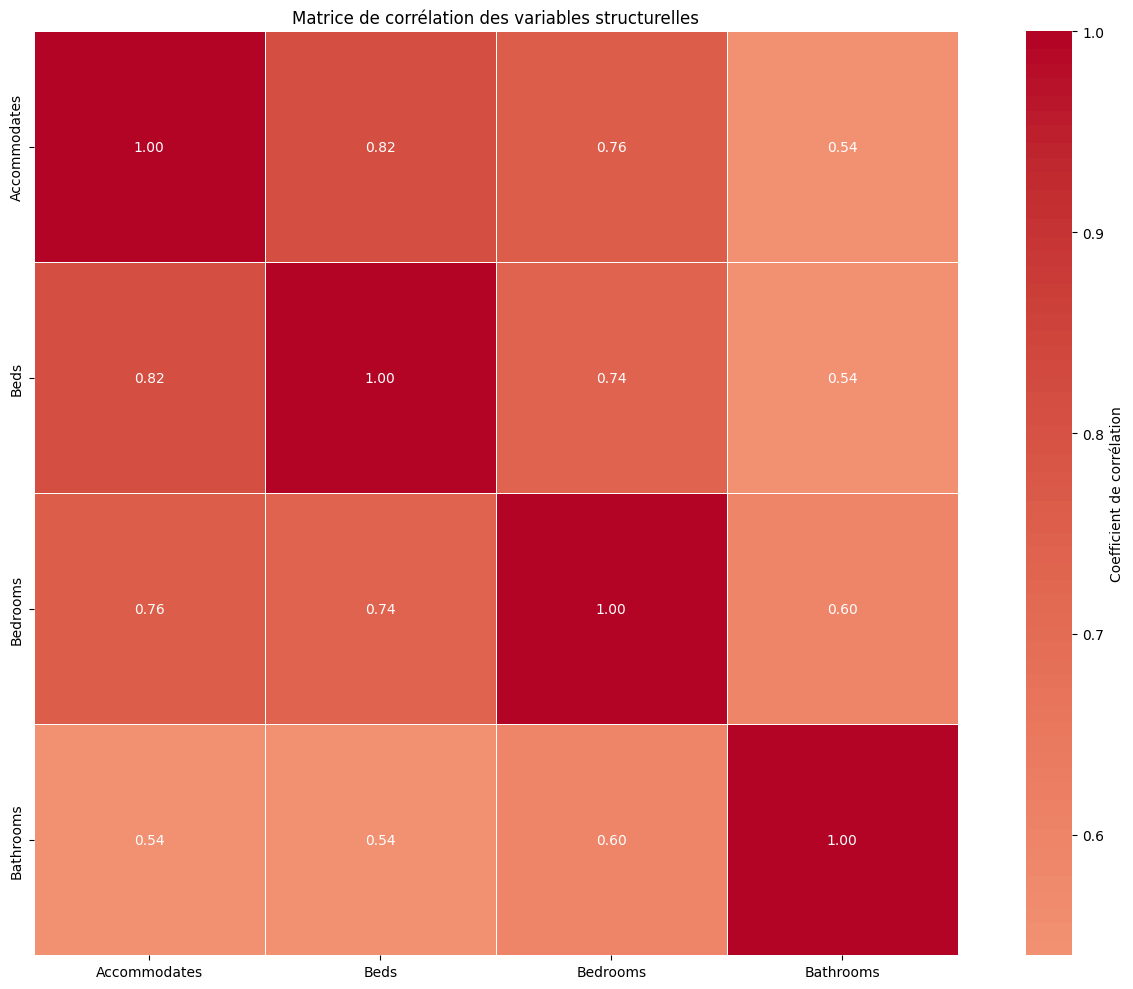

In [59]:
# Correlation heatmap of the structural variables
plt.figure(figsize=(14, 10))
sns.heatmap(
    df[structure].corr().round(2),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Coefficient de corrélation"},
)
plt.title("Matrice de corrélation des variables structurelles")
plt.tight_layout()
plt.show()

The correlation matrix shows strong links between the structural variables:
 - Accommodates - Beds 0.82
 - Accommodates - Bedrooms 0.76
 - Beds - Bedrooms 0.74
 - Bathrooms - Bedrooms 0.60

These strong correlations let us impute with conditional medians: each missing value is filled with the median observed for comparable properties, based on the variable it is most correlated with. This keeps the diversity of properties, where a global median would flatten these differences.

In [60]:
# Compute the medians on the original data, before imputation
med_acc_per_beds = df.groupby("Beds")["Accommodates"].median()
med_beds_per_acc = df.groupby("Accommodates")["Beds"].median()
med_bedrooms_per_acc = df.groupby("Accommodates")["Bedrooms"].median()
med_bathrooms_per_bedrooms = df.groupby("Bedrooms")["Bathrooms"].median()

In [61]:
# Impute from the medians computed on the original data
df["Accommodates"] = df["Accommodates"].fillna(df["Beds"].map(med_acc_per_beds))
df["Beds"] = df["Beds"].fillna(df["Accommodates"].map(med_beds_per_acc))
df["Bedrooms"] = df["Bedrooms"].fillna(df["Accommodates"].map(med_bedrooms_per_acc))
df["Bathrooms"] = df["Bathrooms"].fillna(df["Bedrooms"].map(med_bathrooms_per_bedrooms))

In [62]:
# Check the imputation
df[["Accommodates", "Beds", "Bedrooms", "Bathrooms"]].isna().sum()

Accommodates    0
Beds            0
Bedrooms        0
Bathrooms       0
dtype: int64

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.13 - "Price"</h3>
</div>

Price is a key variable of our analysis. Imputing nearly 8,000 rows would amount to creating fictitious listings, which would directly distort every KPI calculated from the price. Given the small number of rows without a price, they are removed from the dataset.

In [63]:
# Remove missing prices
df = df.dropna(subset=["Price"])

In [64]:
# Check the removal
df["Price"].isna().sum()

np.int64(0)

In [65]:
# Check minimum and maximum prices
print("Min price:", df["Price"].min())
print("Max price:", df["Price"].max())

Min price: 0.0
Max price: 999.0


In [66]:
# Number of rows with a price of 0
print("Prices of 0:", (df["Price"] == 0).sum())

Prices of 0: 22


In [67]:
# Remove prices of 0
df = df[df["Price"] > 0]

In [68]:
# Check the removal
print("Min score:", df["Price"].min())

Min score: 1.0


In [69]:
# Investigate listings under 10
df[df["Price"] < 10][
    ["Price", "City", "Country", "Property Type", "Room Type", "Accommodates"]
].sort_values("Price")

,Price,City,Country,Property Type,Room Type,Accommodates
5871,1.0,Berlin,Germany,Tent,Private room,1.0
89987,1.0,Toronto,Canada,Condominium,Private room,2.0
88784,3.0,Toronto,Canada,House,Private room,2.0
430934,3.0,Chicago,United States,Apartment,Private room,2.0
156297,8.0,Croydon,United Kingdom,Apartment,Private room,1.0
46796,8.0,London,United Kingdom,Apartment,Shared room,1.0
438650,8.0,Paris,France,Apartment,Private room,1.0
5775,9.0,Barcelona,Spain,Bed & Breakfast,Private room,2.0
33143,9.0,Madrid,Spain,Other,Private room,3.0
99417,9.0,Napoli,Italy,Apartment,Private room,6.0


4 listings show abnormally low prices (1 to 3) for properties in countries with strong currencies. These are almost certainly input errors and are removed.

In [70]:
# Remove prices of 4 or less
df = df[df["Price"] > 4]

In [71]:
# Currency check: median price per country
df.groupby("Country")["Price"].median().sort_values(ascending=False)

Country
Denmark           597.0
Hong Kong         465.0
China             252.0
Uruguay           237.0
Australia         121.0
Netherlands       117.0
United States     113.0
Vanuatu           110.0
Cuba              102.0
Vatican City      100.0
Switzerland        98.0
Canada             85.0
Ireland            79.0
Italy              77.0
France             75.0
United Kingdom     70.0
Spain              70.0
Austria            55.0
Belgium            55.0
Germany            45.0
Greece             40.0
Mexico             25.0
Name: Price, dtype: float64

According to the dataset documentation, prices are given in local currency. This is confirmed by the gaps between country medians, caused by different exchange rates. A join with an exchange-rate table is therefore needed.

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.14 - "First Review", "Last Review" & "Review Scores Rating"</h3>
</div>

In [72]:
# Share of missing First Review with 0 reviews
masque = df["First Review"].isna()
pct = (df[masque]["Number of Reviews"] == 0).mean() * 100
print(f"{pct:.1f}% of missing First Review have 0 reviews")

99.8% of missing First Review have 0 reviews


In [73]:
# Share of missing Last Review with 0 reviews
masque = df["Last Review"].isna()
pct = (df[masque]["Number of Reviews"] == 0).mean() * 100
print(f"{pct:.1f}% of missing Last Review have 0 reviews")

99.9% of missing Last Review have 0 reviews


The finding is clear: 99.8% of listings without a first review have no reviews at all, and 99.9% for the last review. This is a logical absence of information, not lost data.
These rows are kept and left as NaT, because here the absence of data is itself information: the listing has never been reviewed, most likely because it is recent or has never been rented. Filling these dates with arbitrary values would distort any time analysis, and deleting them would considerably shrink our sample and reduce its richness.

In [74]:
# Share of missing scores with 0 reviews
masque = df["Review Scores Rating"].isna()
pct = (df[masque]["Number of Reviews"] == 0).mean() * 100
print(f"{pct:.1f}% of missing scores have 0 reviews")

95.2% of missing scores have 0 reviews


In [75]:
# Check Review Scores Rating
print("Min score:", df["Review Scores Rating"].min())
print("Max score:", df["Review Scores Rating"].max())

Min score: 20.0
Max score: 100.0


95.2% of missing Review Scores Rating values have 0 reviews, so the absence is mostly legitimate: a score cannot exist without reviews. The remaining 4.8% are listings with reviews but no overall score, and the available data does not let us determine why. The score therefore stays missing and is treated as such: a NaN, with no deletion or imputation.
No score is below 0 or above 100, so all values are consistent.

In [76]:
# Investigate missing Host Since
df[df["Host Since"].isna()].head(10)

,ID,Name,Host ID,Host Since,Host Total Listings Count,City,Country Code,Country,Latitude,Longitude,...,Security Deposit,Cleaning Fee,Minimum Nights,Availability 365,Number of Reviews,First Review,Last Review,Review Scores Rating,Cancellation Policy,Property Type Grouped
920,12036678,Charming Two Bedroom Apartment!,64430189,NaT,1.0,West Hollywood,US,United States,34.088497,-118.377738,...,0.0,60.0,15.0,0.0,0.0,NaT,NaT,NaN,strict,Appartement
2593,18097057,10mins from the French Quarter!..,124650950,NaT,1.0,New Orleans,US,United States,29.927124,-90.067038,...,100.0,50.0,2.0,83.0,1.0,2017-05-28,2017-05-28,40.0,strict,Appartement
2608,9104571,"243 Franklin Street, 1 Bedroom",47459022,NaT,1.0,Melbourne,AU,Australia,-37.810064,144.956301,...,0.0,0.0,1.0,0.0,0.0,NaT,NaT,NaN,flexible,Appartement
6244,7711359,room w/BALCONY and AMAZING VIEWS,2550257,NaT,1.0,Barcelona,ES,Spain,41.405309,2.173395,...,0.0,0.0,2.0,0.0,1.0,2015-08-05,2015-08-05,NaN,flexible,Appartement
9001,6985409,Lovely Double Room in Beckenham,36624584,NaT,1.0,Beckenham,GB,United Kingdom,51.412014,-0.020338,...,0.0,4.0,1.0,88.0,0.0,NaT,NaT,NaN,flexible,Appartement
10161,17624402,Spacious urban living in Brunswick,119839007,NaT,1.0,Brunswick West,AU,Australia,-37.759625,144.945938,...,0.0,0.0,7.0,358.0,0.0,NaT,NaT,NaN,flexible,Appartement
10162,16543044,Hotel room 10 min from Melbourne airport,52203644,NaT,1.0,Fawkner,AU,Australia,-37.692099,144.958693,...,0.0,0.0,1.0,0.0,0.0,NaT,NaT,NaN,flexible,Hotel / Hostel
21683,8263101,Habitación en piso compartido,37078579,NaT,1.0,Barcelona,ES,Spain,41.380871,2.125722,...,0.0,0.0,1.0,0.0,0.0,NaT,NaT,NaN,flexible,House
22819,2431607,"Bright, Airy Room Share for 2",4973668,NaT,3.0,Brooklyn,US,United States,40.686420,-73.934402,...,0.0,0.0,7.0,229.0,37.0,2014-05-23,2017-04-23,96.0,strict,Appartement
22839,839539,"Awesome, Unique EAST VILLAGE LOFT!!",3200135,NaT,1.0,New York,US,United States,40.728761,-73.984127,...,0.0,50.0,5.0,0.0,0.0,NaT,NaT,NaN,flexible,Appartement


Several rows have no Host Since date, but some have a first review date. Host Since is therefore imputed with the first review date, to keep as many rows as possible.

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.15 - "Host Since"</h3>
</div>

In [77]:
# Impute Host Since with First Review
df["Host Since"] = df["Host Since"].fillna(df["First Review"])

In [78]:
# Remove the remaining empty rows
df = df.dropna(subset=["Host Since"])

In [79]:
# Check the treatment
df["Host Since"].isna().sum()

np.int64(0)

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.16 - "Country Code"</h3>
</div>

Country Code will almost certainly be the key used for the joins, so exploring it is essential.

In [80]:
# Show every country code
df["Country Code"].unique()

<StringArray>
['NL', 'BE', 'GR', 'GB', 'US', 'ES', 'AU', 'CA', 'DE', 'DK', 'IE', 'HK', 'CN',
 'CH', 'FR', 'IT', 'AT', 'MX', 'VU', 'UY', 'CU', 'It', 'VA']
Length: 23, dtype: str

In [81]:
# Investigate the "IT" and "It" codes
print(df[df["Country Code"] == "It"].shape[0], "lignes avec 'It'")
print(df[df["Country Code"] == "IT"].shape[0], "lignes avec 'IT'")

2 lignes avec 'It'
33104 lignes avec 'IT'


In [82]:
# Show the two rows with "It"
lines_it = df[df["Country Code"] == "It"]
lines_it

,ID,Name,Host ID,Host Since,Host Total Listings Count,City,Country Code,Country,Latitude,Longitude,...,Security Deposit,Cleaning Fee,Minimum Nights,Availability 365,Number of Reviews,First Review,Last Review,Review Scores Rating,Cancellation Policy,Property Type Grouped
159712,1553260,¡Urgente! Busco Piso en Madrid,8258846,2013-08-19,1.0,Salerno,It,Italy,40.476713,-3.571890,...,0.0,0.0,1.0,365.0,0.0,NaT,NaT,NaN,flexible,House
311255,1463549,Appartamento NOCE MOSCATA,7842220,2013-07-31,2.0,Dro,It,Italy,45.958855,10.907582,...,0.0,0.0,2.0,78.0,0.0,NaT,NaT,NaN,strict,Appartement


These two rows were clearly typed with a lowercase t but do belong to Italy, so they are corrected.

In [83]:
# Uppercase all country codes
df["Country Code"] = df["Country Code"].str.upper()

In [84]:
# Check
df["Country Code"].unique()

<StringArray>
['NL', 'BE', 'GR', 'GB', 'US', 'ES', 'AU', 'CA', 'DE', 'DK', 'IE', 'HK', 'CN',
 'CH', 'FR', 'IT', 'AT', 'MX', 'VU', 'UY', 'CU', 'VA']
Length: 22, dtype: str

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.17 - "Cancellation Policy"</h3>
</div>

In [85]:
# Explore the cancellation policies
df["Cancellation Policy"].unique()

<StringArray>
[             'strict',            'flexible',            'moderate',
     'super_strict_60',     'super_strict_30',          'strict_new',
        'flexible_new',        'moderate_new', 'super_strict_30_new',
 'super_strict_60_new',           'long_term',          'no_refunds']
Length: 12, dtype: str

In [86]:
# Group the cancellation policies
mapping_policy = {
    "flexible": "Flexible",
    "flexible_new": "Flexible",
    "moderate": "Moderate",
    "moderate_new": "Moderate",
    "strict": "Strict",
    "strict_new": "Strict",
    "super_strict_30": "Strict_30_days",
    "super_strict_30_new": "Strict_30_days",
    "super_strict_60": "Strict_60_days",
    "super_strict_60_new": "Strict_60_days",
    "no_refunds": "Strict",
    "long_term": "Long term",
}

df["Cancellation_Policy_Grouped"] = df["Cancellation Policy"].map(mapping_policy)

In [87]:
# Check the grouping
df["Cancellation_Policy_Grouped"].unique()

<StringArray>
[        'Strict',       'Flexible',       'Moderate', 'Strict_60_days',
 'Strict_30_days',      'Long term']
Length: 6, dtype: str

<div style="background-color: #767676;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Handling duplicates</h2>
</div>

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">2.1 - Duplicated "ID"</h3>
</div>

In [88]:
# Check for duplicated IDs
print("Duplicated IDs:", df["ID"].duplicated().sum())

Duplicated IDs: 2


In [89]:
# Show the rows with a duplicated ID
id_doublons = df[df["ID"].duplicated(keep=False)].sort_values("ID")
id_doublons

,ID,Name,Host ID,Host Since,Host Total Listings Count,City,Country Code,Country,Latitude,Longitude,...,Cleaning Fee,Minimum Nights,Availability 365,Number of Reviews,First Review,Last Review,Review Scores Rating,Cancellation Policy,Property Type Grouped,Cancellation_Policy_Grouped
261737,2832508,"Bethlehem way, Edinburgh , Scotland",14490818,2014-04-20,1.0,Edinburgh,GB,United Kingdom,55.963997,-3.161859,...,15.0,3.0,301.0,24.0,2014-07-22,2016-07-02,92.0,strict,Appartement,Strict
420151,2832508,"Bethlehem way, Edinburgh , Scotland",14490818,2014-04-20,1.0,Edinburgh,GB,United Kingdom,55.963997,-3.161859,...,15.0,3.0,301.0,24.0,2014-07-22,2016-07-02,92.0,strict,Appartement,Strict
61500,12512133,Spacious Central 4 Bed Apartment,67757959,2016-04-18,1.0,Edinburgh,GB,United Kingdom,55.943664,-3.184048,...,40.0,3.0,10.0,1.0,2016-06-22,2016-06-22,60.0,strict,Appartement,Strict
315850,12512133,Spacious Central 4 Bed Apartment,67757959,2016-04-18,1.0,Edinburgh,GB,United Kingdom,55.943664,-3.184048,...,40.0,3.0,10.0,1.0,2016-06-22,2016-06-22,60.0,strict,Appartement,Strict


These are exact duplicates, most likely created during the export, so they are removed.

In [90]:
# Remove the two duplicates
df = df.drop_duplicates(subset=["ID"], keep="first")

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">2.2 - Exact duplicates</h3>
</div>

In [91]:
# Check for fully duplicated rows
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


<div style="background-color: #767676;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Final dataset</h2>
</div>

In [92]:
# Final dataset
df.info()

<class 'pandas.DataFrame'>
Index: 486725 entries, 0 to 494953
Data columns (total 28 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   ID                           486725 non-null  object        
 1   Name                         486725 non-null  str           
 2   Host ID                      486725 non-null  int64         
 3   Host Since                   486725 non-null  datetime64[us]
 4   Host Total Listings Count    486725 non-null  float64       
 5   City                         486725 non-null  str           
 6   Country Code                 486725 non-null  str           
 7   Country                      486725 non-null  str           
 8   Latitude                     486725 non-null  float64       
 9   Longitude                    486725 non-null  float64       
 10  Property Type                486725 non-null  str           
 11  Room Type                    486725 non-nu

After a thorough treatment of missing values, duplicates and anomalies, the final dataset is ready: 486,725 rows and 27 columns, keeping 98% of the information to preserve the richness of our sample. Only First Review, Last Review and Review Scores Rating still have missing values.

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">3.1 - Exporting the dataset</h3>
</div>

In [93]:
df.to_csv("../data/airbnb_listing_clean.csv", index=False, encoding="utf-8-sig")
print(f"File exported: {len(df):,} rows, {df.shape[1]} columns")

File exported: 486,725 rows, 28 columns


<div style="display: flex; background-color: #FF5A5F;" >
<h1 style="margin: auto; padding: 30px; color: white; ">Project 10 - Part 2 - Joining the exchange rates</h1>
</div>

<div style="background-color: #767676;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Loading the file</h2>
</div>

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.1 - Loading, exploring and joining the dataset</h3>
</div>

In [94]:
# Load the dataset
df_conversion = pd.read_csv("../data/taux_conversion.csv", sep=";")

In [95]:
# Dataset size
df_conversion.info()

<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Country Code  210 non-null    str  
 1   2017 rate $   211 non-null    str  
 2   Income Group  265 non-null    str  
dtypes: str(3)
memory usage: 6.3 KB


In [96]:
# Show the first 5 rows
df_conversion.head(5)

,Country Code,2017 rate $,Income Group
0,AW,"1,79",Revenu élevé
1,NaN,NaN,Agrégats
2,AF,"68,02690408",Faible revenu
3,NaN,NaN,Agrégats
4,AO,"165,9159507","Revenu intermédiaire, tranche inférieure"


In [97]:
# Convert the 2017 rate $ column to numbers
df_conversion["2017 rate $"] = (
    df_conversion["2017 rate $"].astype(str).str.replace(",", ".").astype(float)
)

In [98]:
# Join on country code
df = df.merge(df_conversion, on="Country Code", how="left")

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.2 - Unmatched rows after the join</h3>
</div>

In [99]:
# Rows left without an exchange rate
print(df[df["2017 rate $"].isna()]["Country"].value_counts())

Country
Vatican City    2
Cuba            1
Name: count, dtype: int64


After the join on country code, Vatican City and Cuba have no exchange rate: these territories are missing from the official World Bank data. Vatican City uses the euro, and Cuba had a dual-currency system in 2017, so the Cuban row is removed and the Vatican rows are imputed with the euro rate.

In [100]:
# Impute Vatican City's exchange rate
df.loc[df["Country"] == "Vatican City", "2017 rate $"] = 0.885205508

In [101]:
# Remove the Cuba row
df = df[df["Country"] != "Cuba"]

In [102]:
# Check the imputation and the removal
print(df[df["2017 rate $"].isna()]["Country"].value_counts())

Series([], Name: count, dtype: int64)


In [103]:
# Rows left without an income group
print(df[df["Income Group"].isna()]["Country"].value_counts())

Country
Vatican City    2
Name: count, dtype: int64


Vatican City is also missing from the Income Group. As a micro-state enclosed within Italy, and following the same logic as for its exchange rate, its income group is imputed with Italy's.

In [104]:
# Impute Vatican City's income group
df.loc[df["Country"] == "Vatican City", "Income Group"] = "Revenu élevé"

In [105]:
# Check the imputation
print(df[df["Income Group"].isna()]["Country"].value_counts())

Series([], Name: count, dtype: int64)


In [106]:
# Normalise prices in USD
df["prix usd"] = df["Price"] / df["2017 rate $"]
df["prix usd"].describe()

count    486724.000000
mean        119.486438
std         107.331624
min           1.020211
25%          56.484059
50%          90.092794
75%         141.210147
max        1285.752872
Name: prix usd, dtype: float64

The join was successful: prices are now normalised in USD, making listings comparable across countries. The consolidated file is ready for export.

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.3 - Exporting the dataset</h3>
</div>

In [107]:
df.to_csv("../data/airbnb_join.csv", index=False, encoding="utf-8-sig")
print(f"File exported: {len(df):,} rows, {df.shape[1]} columns")

File exported: 486,724 rows, 31 columns


<div style="display: flex; background-color: #FF5A5F;" >
<h1 style="margin: auto; padding: 30px; color: white; ">Project 10 - Part 3 - Distance to major airports</h1>
</div>

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.1 - Loading the dataset</h3>
</div>

In [108]:
# Load the dataset
df_airport = pd.read_csv("../data/airports.csv")

In [109]:
# Descriptive statistics
df_airport.describe()

,id,latitude_deg,longitude_deg,elevation_ft,Unnamed: 15,Unnamed: 16,Unnamed: 17
count,76364.000000,76364.000000,76364.000000,61966.000000,0.0,0.0,0.0
mean,162822.934184,25.695817,-28.900133,1303.019511,NaN,NaN,NaN
std,165642.549516,26.234849,86.150484,1672.252053,NaN,NaN,NaN
min,2.000000,-90.000000,-179.876999,-1266.000000,NaN,NaN,NaN
25%,19239.750000,11.990900,-94.067597,207.000000,NaN,NaN,NaN
50%,40900.500000,35.133470,-69.802264,730.000000,NaN,NaN,NaN
75%,335611.250000,42.671903,23.842905,1617.000000,NaN,NaN,NaN
max,512008.000000,82.750000,179.975700,17372.000000,NaN,NaN,NaN


In [110]:
# Dataset size
df_airport.info()

<class 'pandas.DataFrame'>
RangeIndex: 76364 entries, 0 to 76363
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 76364 non-null  int64  
 1   ident              76364 non-null  str    
 2   type               76364 non-null  str    
 3   name               76364 non-null  str    
 4   latitude_deg       76364 non-null  float64
 5   longitude_deg      76364 non-null  float64
 6   elevation_ft       61966 non-null  float64
 7   continent          39369 non-null  str    
 8   iso_country        76105 non-null  str    
 9   iso_region         76364 non-null  str    
 10  municipality       71313 non-null  str    
 11  scheduled_service  76364 non-null  str    
 12  gps_code           41344 non-null  str    
 13  iata_code          8888 non-null   str    
 14  local_code         32788 non-null  str    
 15  Unnamed: 15        0 non-null      float64
 16  Unnamed: 16        0 non-null    

In [111]:
# Show the first 5 rows
df_airport.head(5)

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,gps_code,iata_code,local_code,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,K00A,NaN,00A,NaN,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,00AA,NaN,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,00AK,NaN,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,00AL,NaN,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,00AN,NaN,00AN,NaN,NaN,NaN


<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.2 - Distance to the nearest airport</h3>
</div>

The BallTree lets us compute real distances on the surface of the globe, and link each property to its nearest international airport with scheduled flights.

In [112]:
# Import BallTree
from sklearn.neighbors import BallTree

In [113]:
# Keep only large airports with scheduled flights
df_airport = df_airport[
    (df_airport["type"] == "large_airport") & (df_airport["scheduled_service"] == "yes")
].copy()

In [114]:
# Build a spatial tree of the airports from their coordinates
tree = BallTree(
    np.radians(df_airport[["latitude_deg", "longitude_deg"]].values), metric="haversine"
)

In [115]:
# Find the nearest large airport for every listing
dist, idx = tree.query(np.radians(df[["Latitude", "Longitude"]].values), k=1)

In [116]:
# Convert the distance from radians to kilometres and add it to the dataset
df["distance_aeroport_km"] = (dist[:, 0] * 6371).round(2)

In [117]:
# Size of the new dataset
df.info()

<class 'pandas.DataFrame'>
Index: 486724 entries, 0 to 486724
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   ID                           486724 non-null  object        
 1   Name                         486724 non-null  str           
 2   Host ID                      486724 non-null  int64         
 3   Host Since                   486724 non-null  datetime64[us]
 4   Host Total Listings Count    486724 non-null  float64       
 5   City                         486724 non-null  str           
 6   Country Code                 486724 non-null  str           
 7   Country                      486724 non-null  str           
 8   Latitude                     486724 non-null  float64       
 9   Longitude                    486724 non-null  float64       
 10  Property Type                486724 non-null  str           
 11  Room Type                    486724 non-nu

In [118]:
# Show the dataset
df.head(5)

,ID,Name,Host ID,Host Since,Host Total Listings Count,City,Country Code,Country,Latitude,Longitude,...,First Review,Last Review,Review Scores Rating,Cancellation Policy,Property Type Grouped,Cancellation_Policy_Grouped,2017 rate $,Income Group,prix usd,distance_aeroport_km
0,4008728,"Luxurious 3 bedroom, centrum, 180m2",20786453,2014-09-01,1.0,Amsterdam,NL,Netherlands,52.365237,4.878250,...,2015-08-02,2016-11-27,89.0,strict,Appartement,Strict,0.885206,Revenu élevé,677.808706,10.00
1,7778612,Luxury apartment in city centre,11964927,2014-02-05,1.0,Amsterdam,NL,Netherlands,52.367309,4.873841,...,2015-09-28,2017-01-19,99.0,strict,Appartement,Strict,0.885206,Revenu élevé,197.694206,9.92
2,8264596,Cosy apartment across Vondelpark,23669273,2014-11-12,1.0,Amsterdam,NL,Netherlands,52.361944,4.866687,...,2015-09-22,2015-09-22,100.0,flexible,Appartement,Flexible,0.885206,Revenu élevé,141.210147,9.16
3,2180729,Spacious City Apartment Oud-West,9238680,2013-10-05,1.0,Amsterdam,NL,Netherlands,52.370146,4.866282,...,2014-05-12,2016-07-19,97.0,flexible,Appartement,Flexible,0.885206,Revenu élevé,146.858553,9.76
4,14463171,Cosy Studio Apartment Center Amsterdam,89112644,2016-08-10,1.0,Amsterdam,NL,Netherlands,52.368818,4.871249,...,2016-08-11,2017-03-06,78.0,moderate,Appartement,Moderate,0.885206,Revenu élevé,90.374494,9.90


<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.3 - Final review of cities per country</h3>
</div>

Cities and countries being at the heart of our study, we now analyse these variables in depth to ensure reliable work in Tableau.

In [119]:
# List of countries
df["Country"].unique()

<StringArray>
[   'Netherlands',        'Belgium',         'Greece', 'United Kingdom',
  'United States',          'Spain',      'Australia',         'Canada',
        'Germany',        'Denmark',        'Ireland',      'Hong Kong',
          'China',    'Switzerland',         'France',          'Italy',
        'Austria',         'Mexico',        'Vanuatu',        'Uruguay',
   'Vatican City']
Length: 21, dtype: str

The 21 countries have clean labels. Let's now look at the cities in each of them.

In [120]:
# Number of cities per country
cities = df.groupby(["Country", "City"]).size().reset_index(name="n_listings")
city_per_country = (
    cities.groupby("Country")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="city count")
)
print(city_per_country)
print(f"Distinct cities: {df.groupby(['Country','City']).ngroups}")

           Country  city count
0        Australia        1355
1    United States         686
2            Spain         650
3            Italy         566
4   United Kingdom         525
5        Hong Kong         277
6          Ireland         199
7           Greece         109
8           Canada         101
9          Denmark          94
10         Belgium          78
11          France          72
12     Switzerland          71
13         Austria          36
14         Germany          29
15     Netherlands          25
16           China          10
17          Mexico           2
18    Vatican City           2
19         Uruguay           1
20         Vanuatu           1
Distinct cities: 4889


We proceed in ascending order of the number of cities per country, to harmonise all the cities within each country.

In [121]:
# Explore Vanuatu, Uruguay, Vatican City and Mexico
country = "Vanuatu", "Uruguay", "Vatican City", "Mexico"
sub = cities[cities["Country"].isin(country)].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

             City  n_listings
Playas de Tijuana           1
          Tijuana           1
         New York           1
    San Francisco           1
             Roma           1
         Vaticano           1


These four countries have too few listings and are removed from the analysis, since their insufficient numbers make them impossible to compare.

In [122]:
# Remove these four countries
country_to_delete = ["Vanuatu", "Mexico", "Vatican City", "Uruguay"]
df = df[~df["Country"].isin(country_to_delete)]

In [123]:
# Explore China
country = "China"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

        City  n_listings
    Shenzhen          15
          深圳          12
         深圳市          11
Shenzhen Shi           5
   Hong Kong           2
    Nanchang           1
          旺角           1
     Qingdao           1
深圳市, 广东省, CN           1
          香港           1


As for the previous countries, with about fifty listings, China is removed because its volume is too low.

In [124]:
# Remove China
df = df[df["Country"] != "China"]

In [125]:
# Explore the Netherlands
country = "Netherlands"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                 City  n_listings
            Amsterdam       15124
              De Pijp           6
           Amstelveen           5
              Jordaan           5
      Watergraafsmeer           5
            Ámsterdam           4
         Badhoevedorp           3
              Zeeburg           2
               Diemen           2
              Centrem           1
        Buitenveldert           1
   Broek in Waterland           1
            Amsterdão           1
             Amsterda           1
                   Am           1
Geuzenveld/Slotermeer           1
         Duivendrecht           1
         Java- eiland           1
              Halfweg           1
              Haarlem           1
              Lijnden           1
              Oud Ade           1
        North Holland           1
            Nederland           1
            Амстердам           1


In [126]:
corrections = {}

In [127]:
# Harmonise Dutch city names
corrections.update(
    {
        "Ámsterdam": "Amsterdam",
        "Amsterdão": "Amsterdam",
        "Amsterda": "Amsterdam",
        "Am": "Amsterdam",
        "Амстердам": "Amsterdam",
        "North Holland": "Jordaan",
        "Nederland": "Amsterdam",
    }
)

In [128]:
# Explore Germany
country = "Germany"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                         City  n_listings
                       Berlin       20501
                           米特           8
                           柏林           4
                       Берлин           3
              Prenzlauer Berg           3
                       Berlín           2
                     Βερολίνο           2
                  Woltersdorf           2
                      Wannsee           2
               Friedrichshain           2
             Bezirk Kreuzberg           2
                        13163           1
                        10711           1
          Königs Wusterhausen           1
                         Köln           1
                    Kreuzberg           1
                 Kleinmachnow           1
                 Johannistahl           1
               Charlottenburg           1
                       Berlim           1
                        Mitte           1
                   Tiergarten           1
                   Schöneberg     

In [129]:
# Harmonise German city names
corrections.update(
    {
        "米特": "Berlin",
        "柏林": "Berlin",
        "Берлин": "Berlin",
        "Berlín": "Berlin",
        "Berlim": "Berlin",
        "Βερολίνο": "Berlin",
    }
)

In [130]:
# Explore Austria
country = "Austria"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                          City  n_listings
                          Wien        6154
                        Vienna        1669
                           维也纳          20
                  Innere Stadt           3
                    Josefstadt           3
                        Wieden           3
                          ウィーン           2
                        Neubau           2
                        Vienne           2
                       Währing           2
                   Brigittenau           2
         2 Bezirk Leopoldstadt           1
                    Alsergrund           1
                     7. Bezirk           1
                     3. Bezirk           1
                Neubau, Vienna           1
                     Mauerbach           1
                     Favoriten           1
                   Landstrasse           1
                       Döbling           1
             Vienna Josefstadt           1
               Vienna 9.Bezirk           1
           

In [131]:
# Harmonise Austrian city names
corrections.update(
    {
        "Wien": "Vienna",
        "Vienne": "Vienna",
        "Neuba, Vienna": "Vienna",
        "Viena": "Vienna",
        "vienna": "Vienna",
        "维也纳": "Vienna",
    }
)

In [132]:
# Explore Switzerland
country = "Switzerland"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                  City  n_listings
                Genève        1423
                Geneva         429
               Carouge          79
                Thônex          25
               Vernier          25
     Le Grand-Saconnex          24
                Meyrin          24
                 Lancy          22
           Chêne-Bourg          22
                  Onex          20
       Chêne-Bougeries          18
              Bellevue          18
               Versoix          18
       Plan-les-Ouates          14
           Grand-Lancy          14
               Cologny          13
    Collonge-Bellerive          11
               Veyrier          10
        Grand-Saconnex           9
               Vésenaz           9
       Pregny-Chambésy           8
                 Vessy           7
              Hermance           7
              Chambésy           7
            Vandœuvres           7
           Petit-Lancy           7
           Les Acacias           6
            Châtelai

In [133]:
# Harmonise Swiss city names
corrections.update({"Genève": "Geneva"})

In [134]:
# Explore France
country = "France"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                     City  n_listings
                    Paris       56017
     Boulogne-Billancourt          61
        Neuilly-sur-Seine          41
      Issy-les-Moulineaux          31
               Saint-Ouen          23
                Vincennes          21
              Saint-Mandé          19
         Levallois-Perret          19
                   Vanves          18
     Le Pré-Saint-Gervais          18
                Montrouge          16
           Ivry-sur-Seine          14
                 Gentilly          14
                 Gaillard          11
        Charenton-le-Pont          11
                   Pantin          10
            Saint-Maurice           8
                    París           8
       Le Kremlin-Bicêtre           8
                Les Lilas           8
            Aubervilliers           8
                   Clichy           8
       Le Kremlin-Bicetre           7
                 Bagnolet           7
                       巴黎           7
        Join

In [135]:
# Harmonise French city names
corrections.update(
    {"París": "Paris", "伊西莱穆利诺": "Issy-les-Moulineaux", "파리": "Paris"}
)

In [136]:
# Explore Belgium
country = "Belgium"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                           City  n_listings
                      Bruxelles        1242
                      Antwerpen        1025
                        Ixelles        1015
                   Saint-Gilles         654
                       Brussels         422
                     Schaerbeek         380
                      Etterbeek         348
                         Forest         275
                          Uccle         245
                        Brussel         219
                        Antwerp         193
                     Anderlecht         186
          Saint-Josse-ten-Noode         147
            Woluwe-Saint-Pierre          98
             Ville de Bruxelles          97
                      Auderghem          96
           Woluwe-Saint-Lambert          85
           Molenbeek-Saint-Jean          79
            Watermael-Boitsfort          62
               City of Brussels          59
                          Evere          52
           Woluwé-Saint-Lambert 

In [137]:
# Harmonise Belgian city names
corrections.update(
    {
        "Bruxelles": "Brussels",
        "Brussel": "Brussels",
        "Antwerpen": "Antwerp",
        "Ville de Bruxelles": "Brussels",
        "City of Brussels": "Brussels",
        "anderlecht": "Anderlecht",
        "Woluwe Saint Pierre": "Woluwe-Saint-Pierre",
        "Woluwé-Saint-Lambert": "Woluwe-Saint-Lambert",
        "Sint-Jans-Molenbeek": "Molenbeek-Saint-Jean",
        "Uccle": "Ukkel",
        "Schaerbeek": "Schaarbeek",
        "Sint-Gillis": "Saint-Gilles",
    }
)

In [138]:
# Explore Denmark
country = "Denmark"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                     City  n_listings
                København       11264
               Copenhagen        2605
            Frederiksberg        1940
              København V          84
              København N          77
                    Valby          75
              København S          74
                  Vanløse          53
                 Hellerup          49
          Frederiksberg C          36
              København Ø          33
              København K          29
             København NV          27
                 Brønshøj          22
                  Kastrup          18
             København SV          13
                  Rødovre          10
                 Hvidovre           7
                   Søborg           6
                      kbh           6
              København v           6
                 Nørrebro           6
           Christianshavn           6
              København s           5
       Vanløse, København           4
            

In [139]:
# Harmonise Danish city names
corrections.update(
    {
        "København": "Copenhagen",
        "København v": "Copenhagen V",
        "København s": "Copenhagen S",
        "København n": "Copenhagen N",
        "København ø": "Copenhagen Ø",
        "København k": "Copenhagen K",
        "København nv": "Copenhagen NV",
        "København sv": "Copenhagen SV",
    }
)

In [140]:
# Explore Canada
country = "Canada"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                           City  n_listings
                        Toronto       12575
                       Montréal        7631
                      Vancouver        5517
                       Montreal        2679
                Ville de Québec        1182
                         Québec         421
                         Quebec         144
                    Québec City         110
                      Westmount          63
                    Quebec City          38
                  Pointe-Claire          26
                         Dorval          23
                         Verdun          22
                 Côte Saint-Luc          16
            Dollard-des-Ormeaux          13
                     North York          13
                        Vaughan          11
                      Hampstead          11
                    Scarborough          10
                      Outremont          10
                            토론토           9
                   Beaconsfield 

In [141]:
# Harmonise Canadian city names
corrections.update(
    {
        "Montréal": "Montreal",
        "Ville de Québec": "Quebec",
        "Québec": "Quebec",
        "Québec City": "Quebec",
        "Quebec City": "Quebec",
        "토론토": "Toronto",
        "多倫多": "Toronto",
        "温哥华": "Vancouver",
        "蒙特利尔": "Montreal",
    }
)

In [142]:
# Explore Greece
country = "Greece"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                                                                                                                                                                                                                                               City  n_listings
                                                                                                                                                                                                                                             Athina        3555
                                                                                                                                                                                                                                             Athens        1041
                                                                                                                                                                                                                                        

In [143]:
# Harmonise Greek city names
corrections.update(
    {
        "Athina": "Athens",
        "Αθήνα": "Athens",
        "Kolonaki, Athens": "Athens",
        "雅典": "Athens",
        "Αθηνα": "Athens",
        "Αθήνα, GR": "Athens",
        "athens": "Athens",
        "Athens, Greece": "Athens",
    }
)

In [144]:
# Explore Ireland
country = "Ireland"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                             City  n_listings
                           Dublin        4516
                      Ballsbridge         152
                        Rathmines         137
                       Drumcondra         118
                         Ringsend         115
                         Ranelagh          96
                       Sandymount          88
                        Blackrock          74
                           Swords          71
                         Malahide          56
                         Clontarf          54
                       Donnybrook          45
                           Sutton          41
                            Lucan          39
                          Rathgar          39
                        Glasnevin          33
                           Santry          32
                          Dundrum          31
                            Cabra          31
                           Artane          30
                          Crumlin 

In [145]:
# Harmonise Irish city names
corrections.update(
    {
        "ダブリン": "Dublin",
        "Дублин": "Dublin",
        "Dublín": "Dublin",
    }
)

In [146]:
# Explore Hong Kong
country = "Hong Kong"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                                              City  n_listings
                                         Hong Kong        3478
                                                香港         175
                                     Tsim Sha Tsui         119
                                          Wan Chai         109
                                           Kowloon          97
                                        Sheung Wan          81
                                            Jordan          79
                                          Mong Kok          61
                                           Central          56
                                      Causeway Bay          51
                                              香港香港          48
                                               尖沙咀          48
                                      Sham Shui Po          39
                            Yau Tsim Mong District          37
                                      Sai Ying Pun     

In [147]:
# Harmonise Hong Kong names
corrections.update(
    {
        "香港": "Hong Kong",
        "香港香港": "Hong Kong",
        "尖沙咀": "Hong Kong",
        "Mongkok": "Mong Kok",
        "旺角": "Mong Kok",
        "香港島": "Wan Chai",
        "九龍": "Hong Kong",
        "佐敦": "Jordan",
        "Mong kok": "Mong Kok",
        "MONG KOK": "Mong Kok",
        "Wanchai": "Wan Chai",
        "Yau Tsim Mong District": "Yau Tsim Mong",
        "油麻地": "Kowloon",
    }
)

In [148]:
# Explore the United Kingdom
country = "United Kingdom"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                                   City  n_listings
                                 London       48629
                              Edinburgh        6112
                             Manchester         809
                               Richmond         261
                             Twickenham         256
                                Croydon         222
                                Londres         193
                                 Harrow         187
                                Edgware         177
                                Wembley         172
                                 Ilford         171
                   Kingston upon Thames         166
                                Bromley         137
                               Hounslow         122
                                 Londra         111
                                Enfield          95
                              Isleworth          84
                                Mitcham          80
            

In [149]:
# Harmonise UK city names
corrections.update(
    {
        "Londres": "London",
        "Londra": "London",
        "哈罗": "Harrow",
        "Edimburgo": "Edinburgh",
        "伦敦": "London",
    }
)

In [150]:
# Explore Italy
country = "Italy"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                                                    City  n_listings
                                                    Roma       18733
                                                    Rome        6062
                                                 Venezia        4057
                                                  Venice        1527
                                                    Lido         195
                                           Lido di Ostia         189
                                                  Trento         132
                                          Riva del Garda         111
                                                    Arco          65
                                                  Mestre          49
                                                Rovereto          43
                                    Madonna di Campiglio          41
                                                 Pinzolo          37
                                  

In [151]:
# Harmonise Italian city names
corrections.update(
    {
        "Rome": "Roma",
        "Venice": "Venezia",
        "Lido": "Venezia",
        "Lido di Ostia": "Ostia",
        "Acilia-castel Fusano-ostia Antica": "Acilia-Castel Fusano-Ostia Antica",
        "罗马": "Roma",
    }
)

In [152]:
# Explore Spain
country = "Spain"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                                         City  n_listings
                                    Barcelona       17463
                                       Madrid       13233
                                        Palma        2808
                                     Pollença         985
                                      Alcúdia         860
                                    Llucmajor         359
                                      Manacor         272
                                       Campos         270
                                 Can Picafort         265
                                     Santanyí         259
                                       Sóller         250
                                     Pollensa         246
                                         Muro         246
                                     Felanitx         231
                                         Inca         202
                                     Sa Pobla         198
              

In [153]:
# Harmonise Spanish city names
corrections.update(
    {
        "Alcúdia": "Alcudia",
        "Artà": "Arta",
        "Barcelone": "Barcelona",
        "Búger": "Buger",
        "Colonia de Sant Pere": "Colonia San Pere",
        "Deià": "Deia",
        "Deyá": "Deia",
        "Llubí": "Llubi",
        "Llucmajor": "Lluchmayor",
        "LLucmajor": "Lluchmayor",
        "Platja de Muro": "Playa de Muro",
        "Pollença": "Pollenca",
        "Pollensa": "Pollenca",
        "Port d'Alcúdia": "Port d'Alcudia",
        "Puerto de Alcudia": "Port d'Alcudia",
        "Puerto Pollença": "Port de Pollença",
        "Sa Ràpita": "Sa Rapita",
        "Santa Ponça": "Santa Ponsa",
        "Santanyí": "Santanyi",
        "Sóller": "Soller",
        "马德里": "Madrid",
    }
)

In [154]:
# Explore the United States
country = "United States"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                                            City  n_listings
                                        New York       19408
                                     Los Angeles       19277
                                        Brooklyn       16344
                                          Austin        9143
                                   San Francisco        8474
                                      Washington        7413
                                       San Diego        6087
                                     New Orleans        5242
                                         Chicago        5172
                                         Seattle        3807
                                        Portland        3532
                                          Boston        3368
                                       Nashville        3191
                                          Queens        2664
                                          Denver        2489
                        

In [155]:
# Harmonise US city names
corrections.update(
    {
        "Brookline": "Brooklyn",
        "brooklyn": "Brooklyn",
        "flushing": "Flushing",
        "Jackson heights": "Jackson Heights",
        "long beach": "Long Beach",
        "Long Island city": "Long Island City",
        "NY": "New York",
        "venice": "Venezia",
    }
)

In [156]:
# Explore Australia
country = "Australia"
sub = cities[cities["Country"] == country].sort_values("n_listings", ascending=False)
print(sub[["City", "n_listings"]].to_string(index=False))

                                      City  n_listings
                                 Melbourne        3012
                               Bondi Beach        1483
                                     Manly         888
                               Surry Hills         797
                                     Bondi         720
                                    Coogee         665
                                 Southbank         631
                                    Sydney         601
                               South Yarra         592
                              Darlinghurst         589
                               North Bondi         569
                                  Randwick         566
                               Saint Kilda         528
                                 Byron Bay         501
                                Paddington         456
                                   Newtown         443
                                   Redfern         439
          

Nothing to change.

In [157]:
# Apply all the city corrections
df["City"] = df["City"].replace(corrections)

Finally, to keep only cities that represent a real market, we keep only cities with at least 10 listings.

In [158]:
# Keep only cities with at least 10 listings
count = df.groupby(["Country", "City"])["ID"].transform("count")
df = df[count >= 10]

In [159]:
# Check the grouping and the filter
print(f"Distinct cities: {df.groupby(['Country','City']).ngroups}")

Distinct cities: 1060


We went from 4,889 cities to 1,060. This major reduction allows a more consistent and relevant comparison between cities. Grouping and harmonisation are complete, and the final dataset is ready for export.

<div style="border: 1px solid #FF5A5F;" >
<h3 style="margin: auto; padding: 20px; color: #767676; ">1.4 - Exporting the final dataset</h3>
</div>

In [160]:
# Export the final dataset
df.to_csv("../data/airbnb_final.tsv", index=False, sep="\t", encoding="utf-8-sig")
print(f"File exported: {len(df):,} rows, {df.shape[1]} columns")

File exported: 478,471 rows, 32 columns


In [161]:
# Size and info of the final dataset
df.info()

<class 'pandas.DataFrame'>
Index: 478471 entries, 0 to 486724
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   ID                           478471 non-null  object        
 1   Name                         478471 non-null  str           
 2   Host ID                      478471 non-null  int64         
 3   Host Since                   478471 non-null  datetime64[us]
 4   Host Total Listings Count    478471 non-null  float64       
 5   City                         478471 non-null  str           
 6   Country Code                 478471 non-null  str           
 7   Country                      478471 non-null  str           
 8   Latitude                     478471 non-null  float64       
 9   Longitude                    478471 non-null  float64       
 10  Property Type                478471 non-null  str           
 11  Room Type                    478471 non-nu

In [162]:
# First 5 rows
df.head(5)

,ID,Name,Host ID,Host Since,Host Total Listings Count,City,Country Code,Country,Latitude,Longitude,...,First Review,Last Review,Review Scores Rating,Cancellation Policy,Property Type Grouped,Cancellation_Policy_Grouped,2017 rate $,Income Group,prix usd,distance_aeroport_km
0,4008728,"Luxurious 3 bedroom, centrum, 180m2",20786453,2014-09-01,1.0,Amsterdam,NL,Netherlands,52.365237,4.878250,...,2015-08-02,2016-11-27,89.0,strict,Appartement,Strict,0.885206,Revenu élevé,677.808706,10.00
1,7778612,Luxury apartment in city centre,11964927,2014-02-05,1.0,Amsterdam,NL,Netherlands,52.367309,4.873841,...,2015-09-28,2017-01-19,99.0,strict,Appartement,Strict,0.885206,Revenu élevé,197.694206,9.92
2,8264596,Cosy apartment across Vondelpark,23669273,2014-11-12,1.0,Amsterdam,NL,Netherlands,52.361944,4.866687,...,2015-09-22,2015-09-22,100.0,flexible,Appartement,Flexible,0.885206,Revenu élevé,141.210147,9.16
3,2180729,Spacious City Apartment Oud-West,9238680,2013-10-05,1.0,Amsterdam,NL,Netherlands,52.370146,4.866282,...,2014-05-12,2016-07-19,97.0,flexible,Appartement,Flexible,0.885206,Revenu élevé,146.858553,9.76
4,14463171,Cosy Studio Apartment Center Amsterdam,89112644,2016-08-10,1.0,Amsterdam,NL,Netherlands,52.368818,4.871249,...,2016-08-11,2017-03-06,78.0,moderate,Appartement,Moderate,0.885206,Revenu élevé,90.374494,9.90
